In [1]:
%env CUDA_VISIBLE_DEVICES=3

env: CUDA_VISIBLE_DEVICES=3


In [2]:
import sys
import os
print(os.getcwd())
sys.path.append('../../..')
from contrib.DMI.ASIP_OSISAF.data import *
from contrib.DMI.ASIP_OSISAF.load_data import *
from src.utils import *
from src.models import *

import matplotlib.pyplot as plt
import torch
import itertools
import geopandas as gpd
from geopandas import GeoSeries
import cartopy.feature as cfeature

datamodule = BaseDataModule(asip_paths=load_data(),
                            osisaf_paths=load_data(type="osisaf"),
                            covariates_paths=load_data("era5"),
                            covariates=["t2m", "istl1", "siconc", "sst", "skt"],
                            mask_path="/dmidata/users/maxb/4dvarnet-starter/contrib/DMI/ASIP_OSISAF/mask_PanArctic.nc",
                            domain_name="arctic_small",
                            domains={'train': {'time': slice('2021-01-01', '2021-12-31',)},
                                     'val': {'time': [ slice('2021-01-01', '2021-06-30',),
                                                       slice('2021-07-01', '2021-12-31',) ]},
                                     'test': {'time': slice('2022-01-01', '2022-01-20',)}},
                            xrds_kw={'patch_dims': {'time': 19, 'yc': 240, 'xc': 240},
                                     'strides': {'time': 1, 'yc': 20, 'xc': 20},
                                     'strides_test': {'time': 1, 'yc': 200, 'xc': 200},
                                     'domain_limits':  dict(xc=slice(-3849750.,3749750.,),
                                                            yc=slice(5849750.,-5349750.,))
                                     },
                            dl_kw={'batch_size': 2, 'num_workers': 0},
                            res=500,
                            pads=[False,False,True],
                            norm_stats =[0,100],
                            norm_stats_covs = [ {'t2m': 270.08, 'istl1': 267.68, 'siconc': 0, 'sst': 276.97, 'skt': 270.50},
                                               {'t2m': 14.67, 'istl1': 7.80, 'siconc': 1, 'sst': 6.82, 'skt': 15.21}
                                             ])
datamodule.setup()

data_loader = datamodule.train_dataloader()
val_dataloader = datamodule.val_dataloader()
test_dataloader = datamodule.test_dataloader()

#k=10
#my_sample = next(itertools.islice(data_loader, k, None))
#print(my_sample[0].shape)

/dmidata/users/maxb/4dvarnet-starter/Notebooks/Notebook_DMI/ASIP_OSISAF


/dmidata/users/maxb/miniconda3/envs/4dvarnet-starter/lib/python3.12/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [3]:
lon = xr.open_dataset(datamodule.train_ds.asip_paths[0]).lon.values
lat = xr.open_dataset(datamodule.train_ds.asip_paths[0]).lat.values
xc = xr.open_dataset(datamodule.train_ds.asip_paths[0]).xc.values
yc = xr.open_dataset(datamodule.train_ds.asip_paths[0]).yc.values
def find_idx(coords,c):
    return np.where(coords==c)[0][0]

# 2. Load the model and run

In [4]:
def plot_batch(batch):

    p = xr.Dataset(data_vars={'asip':(('time','yc','xc'),batch.tgt[:,:,:]),
                          'osisaf':(('time','yc','xc'),batch.coarse[:,:,: ]),
                          't2m':(('time','yc','xc'),batch.t2m[:,:,: ]),
                          'lonv':(('time','yc','xc'),batch.lonv[:,:,: ])},
           coords={'time':np.arange(19),
                   'xc':np.arange(240),
                   'yc':np.arange(240)})
    p.asip.plot(#transform=ccrs.PlateCarree(),
                                        col='time',col_wrap=5,
                                        vmin=-2, vmax=2,
                                        #subplot_kws={'projection': map_proj},
                                        add_colorbar=True,
                                        cmap=plt.cm.seismic,
                                        cbar_kwargs=dict(orientation='horizontal'))
    plt.show()
    p.osisaf.plot(#transform=ccrs.PlateCarree(),
                                        col='time',col_wrap=5,
                                        vmin=-2, vmax=2,
                                        #subplot_kws={'projection': map_proj},
                                        add_colorbar=True,
                                        cmap=plt.cm.seismic,
                                        cbar_kwargs=dict(orientation='horizontal'))
    plt.show()
    p.lonv.plot(#transform=ccrs.PlateCarree(),
                                        col='time',col_wrap=5,
                                        #subplot_kws={'projection': map_proj},
                                        add_colorbar=True,
                                        cmap=plt.cm.seismic,
                                        cbar_kwargs=dict(orientation='horizontal'))
    plt.show()
    p.t2m.plot(#transform=ccrs.PlateCarree(),
                                        col='time',col_wrap=5,
                                        vmin=-2, vmax=2,
                                        #subplot_kws={'projection': map_proj},
                                        add_colorbar=True,
                                        cmap=plt.cm.seismic,
                                        cbar_kwargs=dict(orientation='horizontal'))
    plt.show()

In [5]:
device = 'cuda'

from contrib.DMI.ASIP_OSISAF.UNet import *
from contrib.DMI.ASIP_OSISAF.solver import *
from contrib.DMI.ASIP_OSISAF.models import Lit4dVarNet_ASIP_OSISAF
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

model = Lit4dVarNet_ASIP_OSISAF(solver = src.models.GradSolver(n_step=15,
                                                    lr_grad=1e3,
                                                    prior_cost = SRNNPriorCost(srnn=UNet(in_channels=19,
                                                                num_classes=19)),
                                                    obs_cost = BaseObsCost(),
                                                    grad_mod = ConvLstmGradModel(dim_in=19,dim_hidden=96)).to(device),
                                rec_weight = src.utils.get_last_time_wei(patch_dims =  datamodule.xrds_kw['patch_dims'],
                                                               crop= {'time': 0, 'lat': 20, 'lon': 20}, offset=1,
                                                               dim_order=["time","yc","xc"]),
                                optim_weight = src.utils.get_linear_time_wei(patch_dims = {'time': datamodule.xrds_kw['patch_dims']['time'],
                                                                                 'yc': datamodule.xrds_kw['patch_dims']['yc'],
                                                                                 'xc': datamodule.xrds_kw['patch_dims']['xc']},
                                                                    crop= {'time': 0, 'yc': 20, 'xc': 20}, offset=1,
                                                                    dim_order=["time","yc","xc"]),
                                sr_weight = src.utils.get_uniform_time_wei(patch_dims = {'time': datamodule.xrds_kw['patch_dims']['time'],
                                                                               'yc': datamodule.xrds_kw['patch_dims']['yc'],
                                                                               'xc': datamodule.xrds_kw['patch_dims']['xc']},
                                                                 crop= {'time': 0, 'yc': 20, 'xc': 20}, offset=1,
                                                                 dim_order=["time","yc","xc"]),
                                frcst_lead=7,
                                use_cov=True,                    
                                persist_rw=False,
                                opt_fn=None,
                                domain_limits=dict(xc=slice(-3849750.,3749750.,),
                                                   yc=slice(5849750.,-5349750.,)),
                                training_mode="srnn_only",
                                srnn_training_mode="from_asip",
                                )

/dmidata/users/maxb/4dvarnet-starter/Notebooks/Notebook_DMI/ASIP_OSISAF/../../../contrib/DMI/ASIP_OSISAF/UNet.py:237: FutureWarning: `nn.init.xavier_normal` is now deprecated in favor of `nn.init.xavier_normal_`.
  init.xavier_normal(m.weight)
/dmidata/users/maxb/4dvarnet-starter/Notebooks/Notebook_DMI/ASIP_OSISAF/../../../contrib/DMI/ASIP_OSISAF/UNet.py:238: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  init.constant(m.bias, 0)


## 2.2 Training

In [ ]:
import pytorch_lightning
import torchmetrics
trainer = pytorch_lightning.Trainer(accumulate_grad_batches=1,max_epochs=10,gradient_clip_val=1.0,fast_dev_run=True)
trainer.datamodule = datamodule
trainer.fit(model=model,
            train_dataloaders=datamodule.train_dataloader())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
/dmidata/users/maxb/miniconda3/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


## 2.3 Inference

In [ ]:
from IPython.display import clear_output
from torch.optim import Adam
from tqdm.autonotebook import tqdm

k=56
test_batch = next(itertools.islice(test_dataloader, k, None))

# 4DVarNets scheme 
batch = model.modify_batch(batch)
out, sr = model(test_batch_)

# 3. Plot the results

In [4]:
print(datamodule.test_ds.asip_paths)

['/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220101.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220102.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220103.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220104.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220105.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220106.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220107.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220108.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220109.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosaic_arc_l3_20220110.nc'
 '/dmidata/users/maxb/ASIP_OSISAF_dataset/ASIP_L3/dmi_asip_seaice_mosa

## 3.1 Plot ASIP

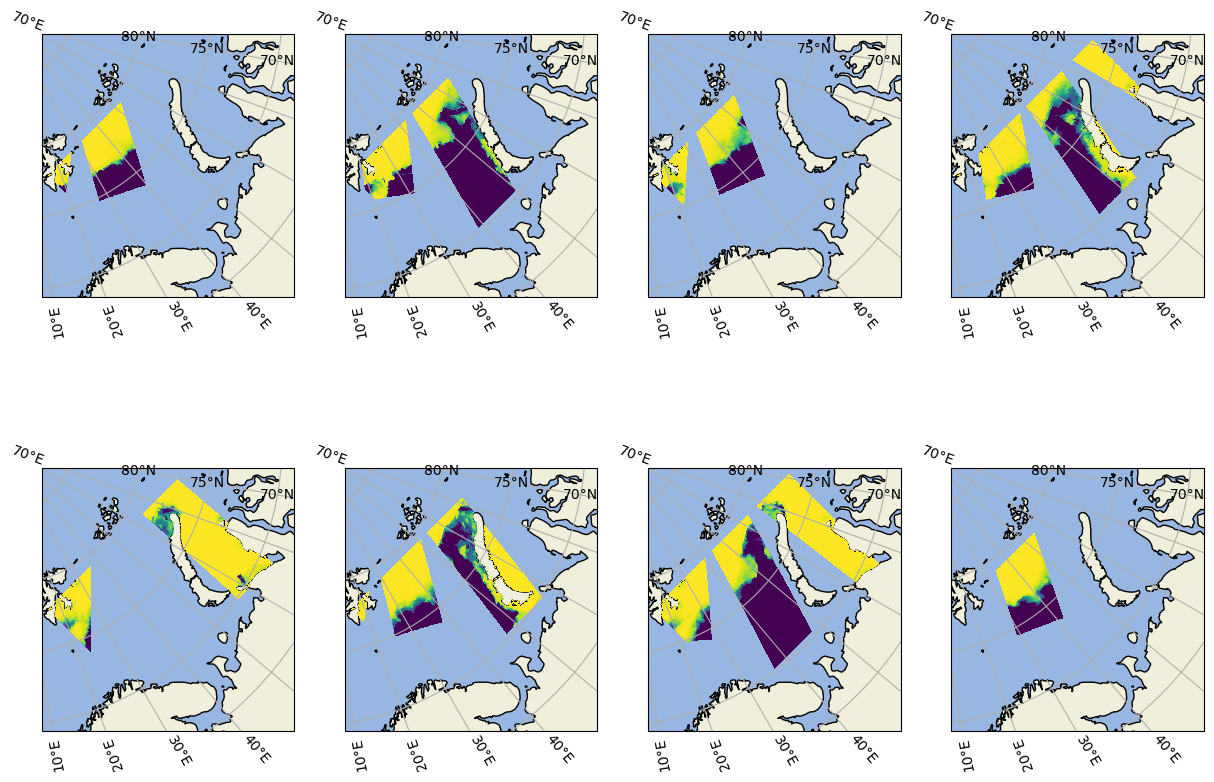

In [5]:
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from random import sample 

map_proj = ccrs.NorthPolarStereo()
map_proj._threshold /= 100.

fig, axs = plt.subplots(2,4,figsize=(15,11),
                       subplot_kw=dict(projection=map_proj))
plt.subplots_adjust(hspace=0.05)
for i in range(8):
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.OCEAN, zorder=0)
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
    axs[i//4,np.mod(i,4)].set_global()
    axs[i//4,np.mod(i,4)].gridlines(draw_labels=True)
    sic = xr.open_dataset(datamodule.test_ds.asip_paths[11+i]).isel(xc=slice(10000,12000),yc=slice(10000,13000)).sic[0]
    axs[i//4,np.mod(i,4)].pcolormesh(sic.lon,sic.lat,sic,transform=ccrs.PlateCarree())
    axs[i//4,np.mod(i,4)].set_extent([np.min(sic.lon),np.max(sic.lon),np.min(sic.lat),np.max(sic.lat)], crs=ccrs.PlateCarree())

## 3.2 Plot ASIP-OSISAF forecast

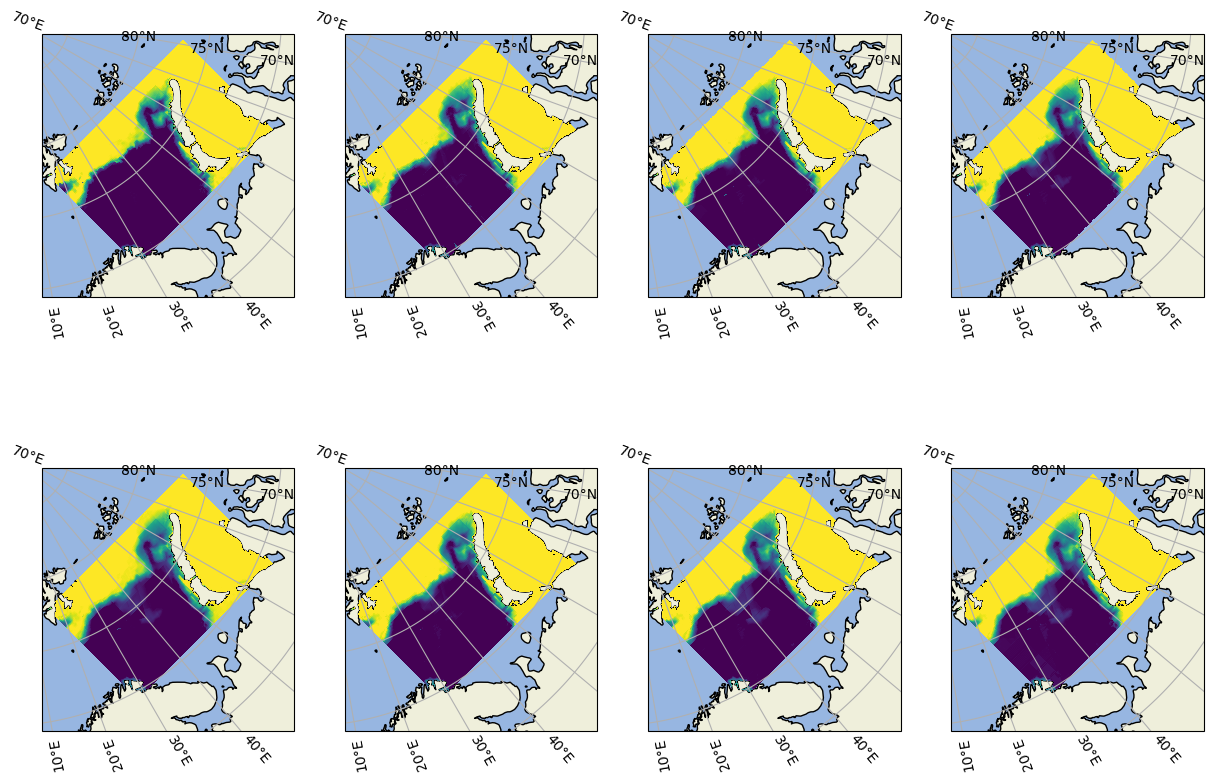

In [6]:
fig, axs = plt.subplots(2,4,figsize=(15,11),
                       subplot_kw=dict(projection=map_proj))
plt.subplots_adjust(hspace=0.05)
start = 20220112
for i in range(8):
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.OCEAN, zorder=0)
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
    axs[i//4,np.mod(i,4)].set_global()
    axs[i//4,np.mod(i,4)].gridlines(draw_labels=True)
    out = xr.open_dataset("/dmidata/users/maxb/results/lightning_logs/version_8359/test_data_20220112_"+str(start+i)+".nc").sel(xc=slice(np.min(sic.xc),np.max(sic.xc)),
                                                                                                                                 yc=slice(np.max(sic.yc),np.min(sic.yc))).out[0]
    axs[i//4,np.mod(i,4)].pcolormesh(out.lon,out.lat,out,transform=ccrs.PlateCarree())
    axs[i//4,np.mod(i,4)].set_extent([np.min(out.lon),np.max(out.lon),np.min(out.lat),np.max(out.lat)], crs=ccrs.PlateCarree())

## 3.3 Plot OSISAF

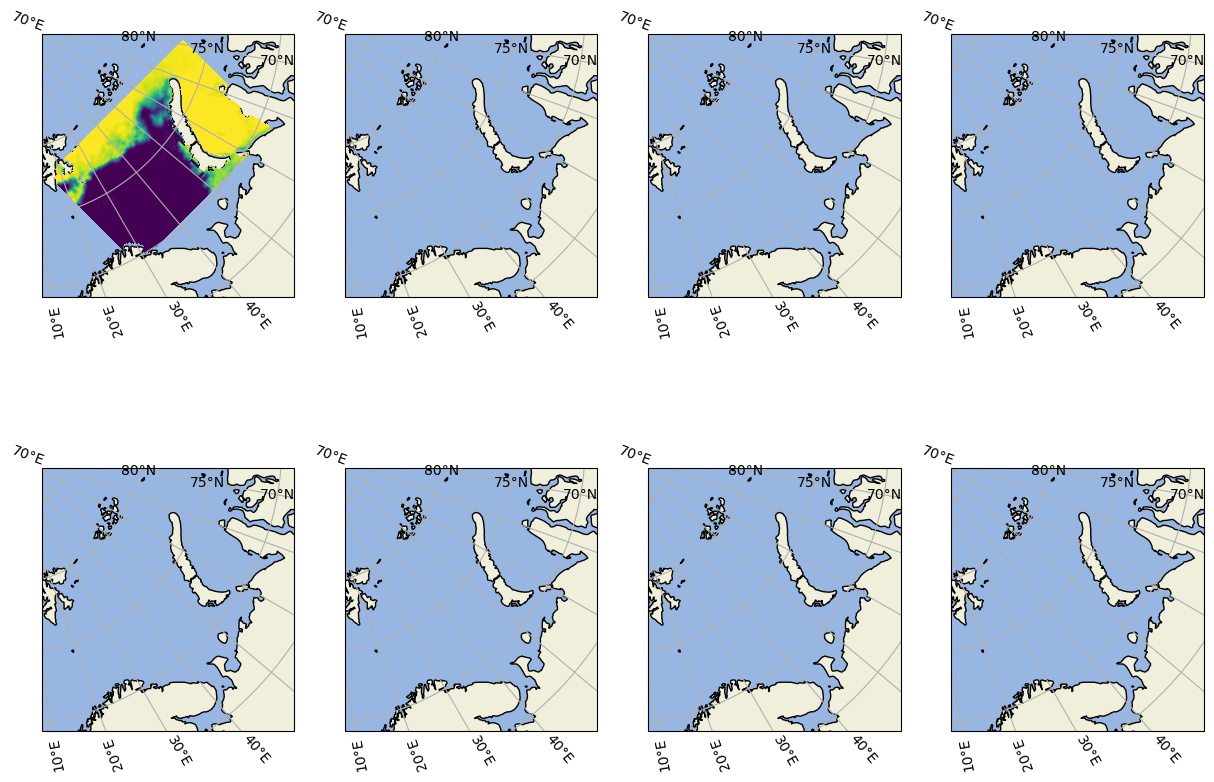

In [7]:
fig, axs = plt.subplots(2,4,figsize=(15,11),
                       subplot_kw=dict(projection=map_proj))
plt.subplots_adjust(hspace=0.05)
start = 20220112
for i in range(8):
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.OCEAN, zorder=0)
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
    axs[i//4,np.mod(i,4)].set_global()
    axs[i//4,np.mod(i,4)].gridlines(draw_labels=True)
    coarse = xr.open_dataset("/dmidata/users/maxb/results/lightning_logs/version_8359/test_data_20220112_"+str(start+i)+".nc").sel(xc=slice(np.min(sic.xc),np.max(sic.xc)),
                                                                                                                                 yc=slice(np.max(sic.yc),np.min(sic.yc))).coarse[0]
    axs[i//4,np.mod(i,4)].pcolormesh(coarse.lon,coarse.lat,coarse,transform=ccrs.PlateCarree())
    axs[i//4,np.mod(i,4)].set_extent([np.min(coarse.lon),np.max(coarse.lon),np.min(coarse.lat),np.max(coarse.lat)], crs=ccrs.PlateCarree())

## 3.4 Plot SR(OSISAF)

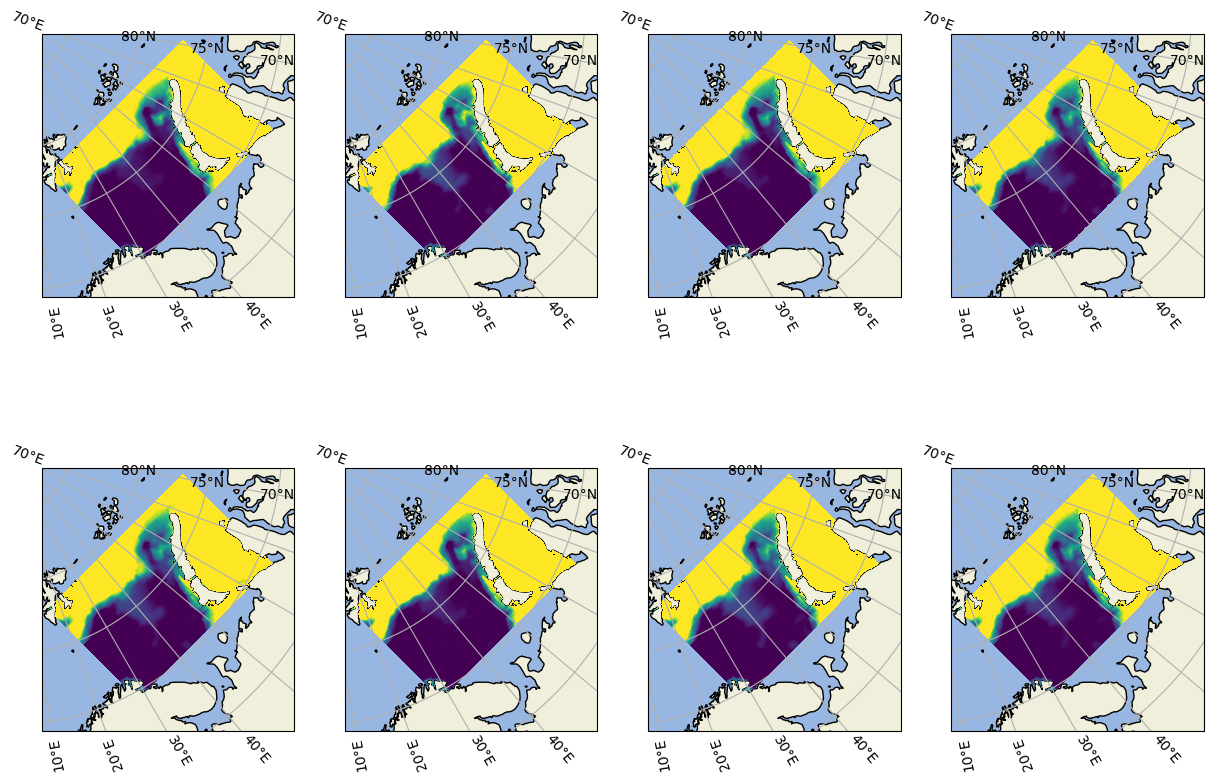

In [9]:
fig, axs = plt.subplots(2,4,figsize=(15,11),
                       subplot_kw=dict(projection=map_proj))
plt.subplots_adjust(hspace=0.05)
start = 20220112
for i in range(8):
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.OCEAN, zorder=0)
    axs[i//4,np.mod(i,4)].add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
    axs[i//4,np.mod(i,4)].set_global()
    axs[i//4,np.mod(i,4)].gridlines(draw_labels=True)
    sr = xr.open_dataset("/dmidata/users/maxb/results/lightning_logs/version_8359/test_data_20220112_"+str(start+i)+".nc").sel(xc=slice(np.min(sic.xc),np.max(sic.xc)),
                                                                                                                                 yc=slice(np.max(sic.yc),np.min(sic.yc))).sr[0]
    axs[i//4,np.mod(i,4)].pcolormesh(sr.lon,sr.lat,sr,transform=ccrs.PlateCarree())
    axs[i//4,np.mod(i,4)].set_extent([np.min(sr.lon),np.max(sr.lon),np.min(sr.lat),np.max(sr.lat)], crs=ccrs.PlateCarree())